<a href="https://colab.research.google.com/github/Bubukisapisa/ML_education/blob/main/LSTM_%D0%B4%D0%BB%D1%8F_%D0%BF%D1%80%D0%BE%D0%B3%D0%BD%D0%BE%D0%B7%D1%83%D0%B2%D0%B0%D0%BD%D0%BD%D1%8F_%D1%87%D0%B0%D1%81%D0%BE%D0%B2%D0%B8%D1%85_%D1%80%D1%8F%D0%B4%D1%96%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Давайте подивимося, як LSTM можна використовувати для побудови нейронної мережі прогнозування часових.

Будемо працювати з задачею прогнозування кількості пасажирів міжнародних авіаліній. З цим набором даних ми вже працювали в лекції "Time Series Analysis" і ви зможете порівняти результати :)

Задача полягає в тому, щоб за заданими роком і місяцем передбачити кількість пасажирів міжнародних авіаліній в одиницях виміру 1,000. Дані охоплюють період з січня 1949 року по грудень 1960 року, тобто 12 років, зі 144 спостереженнями.

Це регресійна задача. Тобто, знаючи кількість пасажирів (в тисячах) за останні місяці, можна передбачити, якою буде кількість пасажирів у наступному місяці. Набір даних має лише одну характеристику: "Кількість пасажирів" - `Passengers`.

Далі вже наведений код для читання даних, але нам їх ще треба буде трошки обробити.

In [1]:
from sklearn.model_selection import train_test_split
import torch
from torch import tensor
from torch import nn

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

# Завантаження даних
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)
df.set_index('Month', inplace=True)
display(df.head())

,Passengers
Month,
1949-01,112
1949-02,118
1949-03,132
1949-04,129
1949-05,121


In [3]:
df.sort_index(inplace=True)

**Завдання 1.** Створіть змінну типу `numpy.ndarray`, яка містить значення кількості пасажирів в форматі `float32`. Такий формат даних нам треба для тренування нейромережі.

In [4]:
data_np = df.Passengers.astype('float32').to_numpy()

In [5]:
data_np

array([112., 118., 132., 129., 121., 135., 148., 148., 136., 119., 104.,
       118., 115., 126., 141., 135., 125., 149., 170., 170., 158., 133.,
       114., 140., 145., 150., 178., 163., 172., 178., 199., 199., 184.,
       162., 146., 166., 171., 180., 193., 181., 183., 218., 230., 242.,
       209., 191., 172., 194., 196., 196., 236., 235., 229., 243., 264.,
       272., 237., 211., 180., 201., 204., 188., 235., 227., 234., 264.,
       302., 293., 259., 229., 203., 229., 242., 233., 267., 269., 270.,
       315., 364., 347., 312., 274., 237., 278., 284., 277., 317., 313.,
       318., 374., 413., 405., 355., 306., 271., 306., 315., 301., 356.,
       348., 355., 422., 465., 467., 404., 347., 305., 336., 340., 318.,
       362., 348., 363., 435., 491., 505., 404., 359., 310., 337., 360.,
       342., 406., 396., 420., 472., 548., 559., 463., 407., 362., 405.,
       417., 391., 419., 461., 472., 535., 622., 606., 508., 461., 390.,
       432.], dtype=float32)

Очікуваний результат:
```array([112., 118., 132., 129., 121.], dtype=float32)```

**Завдання 2**. Розбийте дані на тренувальні і валідаційні у співвідношенні 67% йде у тренування, 33 - у валідацію. Памʼятаємо, що ми працюємо з tim series, відповідно, навчаємось на давніших, валідуємось - на новіших.

In [6]:
train_df, test_df = train_test_split(data_np, test_size=0.33, shuffle=False)

**Завдання 3**.

Реалізуйте функцію `create_dataset`, яка перетворить одномірний часовий ряд (набір даних) у формат, придатний для тренування нейромережі.

Функція повинна приймати два аргументи:
- `dataset` — numpy-масив часового ряду,
- `lookback` — кількість попередніх кроків, які використовуватимуться для передбачення.

Функція повинна повернути два **тензори** PyTorch:
- `X` — набір ознак (вікно попередніх значень),
- `y` — цільові значення (наступні після вікна кроки).

Дані ми будемо подавати моделі в наступному форматі:
`
tensor([[112.],
        [118.],
        [132.],
        [129.],
        [121.]])
`
Відповідно першою розмірністю буде йти розмір вхідного батча, а другою - розмір вхіднизх даних і в нас це 1, бо лише одне значення на вході щоразу.

Після виконання завдання запустіть код нижче. Ми будемо передбачати на основі кількості пасажирів в попередній день кількість пасажирів в наступний, тому `lookback == 1`.

In [7]:
len(train_df)

96

In [8]:
def create_dataset(dataset, lookback):
  X, y = [], []

  for i in range(len(dataset) - lookback):
    window = dataset[i: i+lookback]
    target = dataset[i+lookback]

    X.append(window)
    y.append(target)

  X = tensor(X).unsqueeze(-1)
  y = tensor(y).unsqueeze(-1)

  return X,y

In [9]:
lookback = 1
X_train, y_train = create_dataset(train_df, lookback=lookback)
X_test, y_test = create_dataset(test_df, lookback=lookback)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([95, 1, 1]) torch.Size([95, 1])
torch.Size([47, 1, 1]) torch.Size([47, 1])


/tmp/ipykernel_30204/1791689579.py:11: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  X = tensor(X).unsqueeze(-1)


Очікуваний результат:
```
torch.Size([95, 1]) torch.Size([95, 1])
torch.Size([47, 1]) torch.Size([47, 1])
```

**Завдання 4**.

Зверніть увагу на розмірності в попередньому завданні. Ми
З допомогою модуля `torch.nn` опишіть клас `AirModel`, який є нейронною мережею для прогнозування кількості пасажирів за допомогою LSTM.

1. **Конструктор класу** повинен приймати параметри `hidden_size`, `num_layers` та ініціювати шари:
   - LSTM-шар з наступними параметрами:
     - `input_size` — кожна точка часового ряду є окремим входом,,
     - `hidden_size` — заданий в конструкторі класу мережі,
     - `num_layers=1` — кількість шарів LSTM, задана в конструкторі мережі,
     - `batch_first=True` — визначає, що першим виміром є розмір батчу.
   - Лінійний шар (`nn.Linear`) для перетворення виходу LSTM на прогноз однієї точки.

2. **Метод forward** повинен виконувати наступні дії:
   - Передати вхідний тензор через LSTM-шар і отримати виходи (ігноруючи приховані стани).
   - Пропустити вихід LSTM через лінійний шар для отримання остаточного прогнозу.

Створіть об'єкт класу `AirModel` зі значеннями параметрів `hidden_size=50`, `num_layers=1` і протестуйте роботу моделі на вхідному тензорі `tensor([[112.]])`. На цьому етапі ми маємо переконатись, що модель здатна генерувати передбачення з рандомно ініційованими вагами.

In [10]:
class AirModel(nn.Module):
  def __init__(self, input_size, hidden_size, num_layers):
    super(AirModel, self).__init__()
    self.hidden_size = hidden_size
    self.num_layers = num_layers

    self.lstm = nn.LSTM(input_size, self.hidden_size, num_layers=1, batch_first=True)

    self.linear = nn.Linear(hidden_size, out_features=1)

  def forward(self, x):
    out, _ = self.lstm(x)
    out = self.linear(out[:, -1, :])

    return out

In [11]:
airmodel = AirModel(1, 50, 1)

In [12]:
airmodel.forward(tensor([[112.]]).unsqueeze(-1))

tensor([[0.1758]], grad_fn=<AddmmBackward0>)

**Завдання 5**.

Створіть об'єкт DataLoader для завантаження даних, використовуючи тренувальні вибірки `X_train` та `y_train`. Ваш DataLoader повинен виконувати наступні вимоги:

1. Використовувати клас `TensorDataset`, щоб об'єднати тензори ознак `X_train` і цільових значень `y_train`.
2. Дані повинні завантажуватися невеликими батчами розміром 8 за допомогою параметра `batch_size`.
3. Використовувати параметр `shuffle=True`, щоб дані перемішувалися перед кожною епохою тренування.


In [13]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

In [14]:
dataset = TensorDataset(X_train, y_train)

loader = DataLoader(dataset, batch_size=8, shuffle=True)

**Завдання 6**.

1. Реалізуйте навчання нейронної мережі `AirModel` для прогнозування часових рядів, використовуючи Adam-оптимізатор та функцію втрат MSE (середньоквадратичну похибку).
2. Створіть цикл тренування для 2000 епох, у якому на кожній епосі:
   - Виконуйте крок тренування моделі (прямий прохід, обчислення похибки, зворотний прохід і оновлення ваг).
   - Підраховуйте середню похибку на кожному батчі даних і зберігайте її у списку `losses`.
3. Раз на 100 епох проводьте валідацію моделі:
   - Перевіряйте модель на тренувальних та тестових даних без оновлення ваг.
   - Обчислюйте корінь середньоквадратичної похибки (RMSE) для тренувальної та тестової вибірок і виводьте результати на екран.
   
**Примітка:**
- Використовуйте вже створений `DataLoader` для отримання батчів даних.
- Валідацію виконуйте в режимі `eval()`, вимикаючи обчислення градієнтів з `torch.no_grad()`.

**Приклад виходу:**
```
Epoch 0: train RMSE 12.3456, test RMSE 15.6789
Epoch 100: train RMSE 9.8765, test RMSE 12.3456
...
```

In [15]:
from sklearn.metrics import root_mean_squared_error as rmse

In [16]:
loss_fn = nn.MSELoss()

In [17]:
epoch = 2000
optimizer = torch.optim.Adam(airmodel.parameters(), lr=0.001)

losses = []

for i in range(1, epoch+1):
  for X_batch, y_batch in loader:
    optimizer.zero_grad()

    output = airmodel.forward(X_batch)
    loss = loss_fn(output, y_batch)
    losses.append(loss.item())
    loss.backward()

    optimizer.step()

  if i % 100 == 0 or i == 1:
    with torch.no_grad():
      y_pred_train = airmodel(X_train)
      y_pred_test = airmodel(X_test)
      rmse_train = torch.sqrt(loss_fn(y_pred_train, y_train))
      rmse_test = torch.sqrt(loss_fn(y_pred_test, y_test))
      print(f"Epoch {i}: train RMSE {rmse_train:.4f}, test RMSE {rmse_test:.4f}")


Epoch 1: train RMSE 225.5953, test RMSE 421.9773
Epoch 100: train RMSE 185.0354, test RMSE 379.5268
Epoch 200: train RMSE 151.7758, test RMSE 343.6324
Epoch 300: train RMSE 123.1752, test RMSE 311.0615
Epoch 400: train RMSE 99.8442, test RMSE 281.6158
Epoch 500: train RMSE 81.3968, test RMSE 255.1638
Epoch 600: train RMSE 65.1401, test RMSE 229.7899
Epoch 700: train RMSE 52.4783, test RMSE 206.6433
Epoch 800: train RMSE 43.4639, test RMSE 185.8683
Epoch 900: train RMSE 36.1240, test RMSE 167.7581
Epoch 1000: train RMSE 31.7022, test RMSE 152.3590
Epoch 1100: train RMSE 29.2659, test RMSE 139.8990
Epoch 1200: train RMSE 28.2810, test RMSE 129.0766
Epoch 1300: train RMSE 27.6153, test RMSE 121.1341
Epoch 1400: train RMSE 26.8702, test RMSE 117.2004
Epoch 1500: train RMSE 26.5831, test RMSE 110.1009
Epoch 1600: train RMSE 24.7828, test RMSE 106.3074
Epoch 1700: train RMSE 25.2943, test RMSE 105.8732
Epoch 1800: train RMSE 23.6106, test RMSE 102.1619
Epoch 1900: train RMSE 23.3615, test RM

**Завдання 7.** Побудуйте графік лосів. Зробіть висновок з графіку, чи навчилась модель?

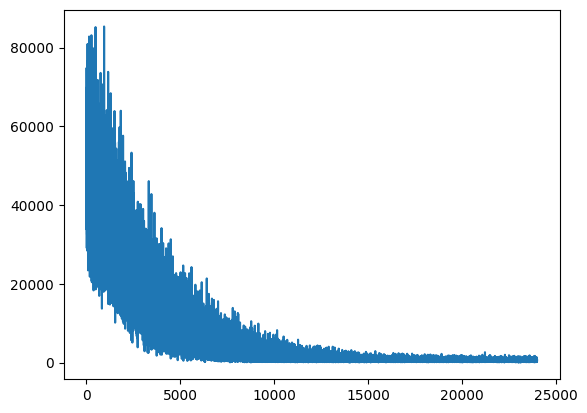

In [18]:
plt.plot(losses)

Модель навчилась, але не факт, що точно)

Доволі неочікувано, що середньоквадратичне відхилення тестового набору даних буде на порядок більшим за одиниці в нашому наборі даних. Середньоквадратичне відхилення 100 означає, що прогноз і фактичне значення будуть відрізнятися в середньому на 100 (тобто, 100 000 пасажирів у цьому наборі даних).



Щоб краще зрозуміти якість прогнозу, ви можете побудувати графік з кодом нижче (а ще нижче - описано, що відбувається в цьому коді, бо це теж корисно зрозуміти):

In [29]:
model = airmodel
train_size = len(X_train) + lookback
timeseries = data_np #df['Passengers'].values.astype(float)

/tmp/ipykernel_30204/311553601.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  train_plot[lookback:train_size] = model(X_train)[:, -1]
/tmp/ipykernel_30204/311553601.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  test_plot[train_size+lookback:len(timeseries)] = model(X_test)[:, -1]


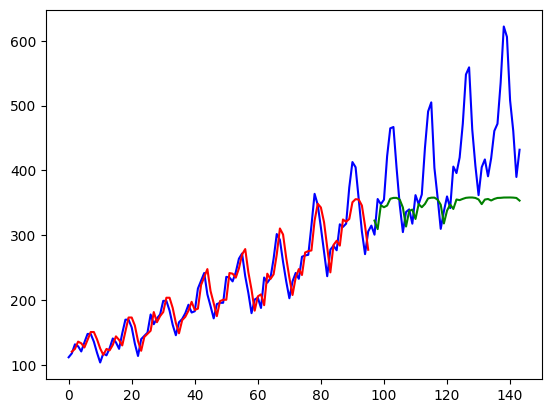

In [30]:
def plot_predicts():
  with torch.no_grad():
      # Зсув прогнозів для тренувальних даних
      train_plot = np.ones_like(timeseries) * np.nan
      y_pred = model(X_train)
      y_pred = y_pred[:, -1]
      train_plot[lookback:train_size] = model(X_train)[:, -1]

      # Зсув прогнозів для тестових даних
      test_plot = np.ones_like(timeseries) * np.nan
      test_plot[train_size+lookback:len(timeseries)] = model(X_test)[:, -1]

  # Візуалізація результатів
  plt.plot(timeseries, c='b')  # Реальні дані
  plt.plot(train_plot, c='r')  # Прогнози на тренувальних даних
  plt.plot(test_plot, c='g')   # Прогнози на тестових даних
  plt.show()

plot_predicts()

**Що відбувається в коді вище.** В цьому коді здійснюється процес прогнозування часових рядів за допомогою LSTM моделі, а також виведення графіку, який показує реальні значення, тренувальні та тестові прогнози. Ось що відбувається на кожному етапі:

1. **`torch.no_grad()`**: Цей контекстний менеджер вимикає обчислення градієнтів, що означає, що під час прогнозування не будуть зберігатися проміжні обчислення для зворотного проходу (backpropagation). Це підвищує ефективність під час прогнозування і зменшує використання пам'яті.

2. **Зсув прогнозів для тренувальних даних:**
   - Створюється масив `train_plot`, який має такий самий розмір, як і часовий ряд (`timeseries`), і заповнюється значеннями NaN (`np.nan`), щоб залишити місце для реальних значень.
   - Модель передбачає виходи для тренувальних даних `X_train`.
   - Використовується лише останнє передбачене значення для кожного входу LSTM (`y_pred[:, -1]`).
   - Прогнози зсуваються, починаючи з індексу `lookback` до кінця тренувальних даних (індекс `train_size`). Цей зсув потрібен, щоб зробити прогноз на основі попередніх даних і відобразити його на правильній частині графіку.

3. **Зсув прогнозів для тестових даних:**
   - Створюється масив `test_plot`, який також заповнюється NaN.
   - Прогнози для тестових даних додаються з індексу `train_size + lookback` до кінця реальних даних, щоб відобразити, де модель починає прогнозувати тестову вибірку.

4. **Побудова графіка:**
   - `plt.plot(timeseries, c='b')`: Виводить реальні значення часового ряду (синя лінія).
   - `plt.plot(train_plot, c='r')`: Виводить тренувальні прогнози (червона лінія).
   - `plt.plot(test_plot, c='g')`: Виводить тестові прогнози (зелена лінія).

**Чому це робиться:**
- Зсув прогнозів для тренувальних і тестових даних дозволяє візуально зрівняти, наскільки добре модель прогнозує як на тренувальній, так і на тестовій вибірках. Зазвичай, червона лінія (тренувальні прогнози) повинна точно відповідати синій лінії (реальні дані), а зелена лінія (тестові прогнози) дає змогу побачити, наскільки модель добре працює на нових даних, яких вона раніше не бачила.

**Завдання 8**. Навчіть модель з hidden_size=100 та порівняйте результати прогнозів з попередніми.

In [31]:
airmodel = AirModel(1, 100, 1)

In [32]:
epoch = 2000
optimizer = torch.optim.Adam(airmodel.parameters(), lr=0.001)

losses = []

for i in range(1, epoch+1):
  for X_batch, y_batch in loader:
    optimizer.zero_grad()

    output = airmodel.forward(X_batch)
    loss = loss_fn(output, y_batch)
    losses.append(loss.item())
    loss.backward()

    optimizer.step()

  if i % 100 == 0 or i == 1:
    with torch.no_grad():
      y_pred_train = airmodel(X_train)
      y_pred_test = airmodel(X_test)
      rmse_train = torch.sqrt(loss_fn(y_pred_train, y_train))
      rmse_test = torch.sqrt(loss_fn(y_pred_test, y_test))
      print(f"Epoch {i}: train RMSE {rmse_train:.4f}, test RMSE {rmse_test:.4f}")


Epoch 1: train RMSE 225.0648, test RMSE 421.4139
Epoch 100: train RMSE 149.7079, test RMSE 341.3451
Epoch 200: train RMSE 100.3884, test RMSE 282.3609
Epoch 300: train RMSE 70.8751, test RMSE 238.4923
Epoch 400: train RMSE 50.7735, test RMSE 201.8336
Epoch 500: train RMSE 38.2786, test RMSE 172.4874
Epoch 600: train RMSE 31.3377, test RMSE 149.3797
Epoch 700: train RMSE 27.6391, test RMSE 131.3689
Epoch 800: train RMSE 26.6068, test RMSE 119.6510
Epoch 900: train RMSE 25.7895, test RMSE 111.6060
Epoch 1000: train RMSE 23.6495, test RMSE 103.5328
Epoch 1100: train RMSE 23.4067, test RMSE 99.0536
Epoch 1200: train RMSE 23.3752, test RMSE 95.6808
Epoch 1300: train RMSE 23.1495, test RMSE 93.5313
Epoch 1400: train RMSE 23.0321, test RMSE 91.2592
Epoch 1500: train RMSE 23.0027, test RMSE 89.8466
Epoch 1600: train RMSE 23.1925, test RMSE 89.2585
Epoch 1700: train RMSE 24.0369, test RMSE 89.8289
Epoch 1800: train RMSE 22.9355, test RMSE 87.7285
Epoch 1900: train RMSE 23.1586, test RMSE 88.207

In [34]:
model = airmodel
train_size = len(X_train) + lookback
timeseries = data_np #df['Passengers'].values.astype(float)

/tmp/ipykernel_30204/311553601.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  train_plot[lookback:train_size] = model(X_train)[:, -1]
/tmp/ipykernel_30204/311553601.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  test_plot[train_size+lookback:len(timeseries)] = model(X_test)[:, -1]


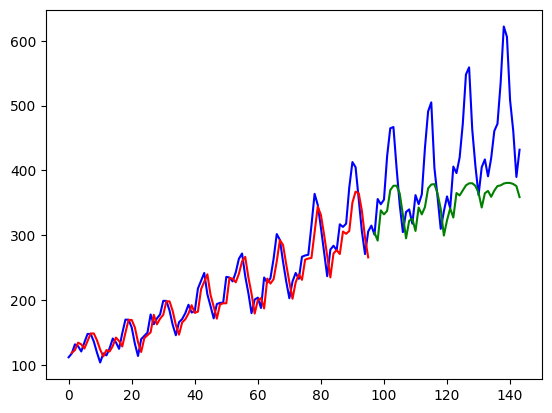

In [35]:
plot_predicts()